In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

## Load Data

In [2]:
# If running on colab you can download the data using gdown. Uncomment the below code. 
# import gdown
# !gdown 1JTvMkEaR3AxqAagYzfLebnS_RavA7agR #x_train_img.npz
# !gdown 1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1 #x_test_img.npz
# !gdown 1tED7-ZgWT0ONtohOD1BCCrlTvXfQM6L0 #x_train.csv
# !gdown 1k36wEmeaks1pg2Q5t3aW3e24uxDaUll8 #x_test.csv
# !gdown 1J2fEdFSfZnTJ9YwxNnB8qDEOrIOkqbkg #y_train.csv

In [3]:
img_file = "x_train_img.npz"
metadata_file = "x_train.csv"
y_file = "y_train.csv"
img_test_file = "x_test_img.npz"

In [4]:
X_dev = pd.read_csv(metadata_file)
y_dev = pd.read_csv(y_file)
X_test = pd.read_csv("x_test.csv")

In [5]:
columns = X_dev.columns
columns


Index(['patient_id', 'img_id', 'smoke', 'drink', 'background_father',
       'background_mother', 'age', 'pesticide', 'gender',
       'skin_cancer_history', 'cancer_history', 'has_piped_water',
       'has_sewage_system', 'fitspatrick', 'region', 'diameter_1',
       'diameter_2', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation'],
      dtype='object')

In [6]:
# Function and code to load images
def load_img_data(file_path):
    with np.load(file_path) as data:
        img = data['images']
        ids = data['image_ids']
    print(f"Successfully loaded {img.shape[0]} images.")  
    return img, ids

imgs, img_ids = load_img_data(img_file)
imgs_test, img_ids_test = load_img_data(img_test_file)
print(img_ids.shape, imgs.shape)
print(img_ids_test.shape, imgs_test.shape)

# Make sure the IDs match and are in the same order
assert np.all(img_ids == X_dev['img_id']), "Image IDs in metadata and image data do not match"
assert np.all(img_ids_test == X_test['img_id']), "Image IDs in metadata and image data do not match"

Successfully loaded 1178 images.
Successfully loaded 296 images.
(1178,) (1178, 256, 256, 3)
(296,) (296, 256, 256, 3)


In [7]:
def extract_image_features(imgs, X):
    """
    Extract image features from a batch of images and add them as columns to the DataFrame X.
    
    Parameters:
    imgs (numpy.ndarray): Array of images with shape (N, H, W, C)
    X (pandas.DataFrame): DataFrame to which features will be added
    
    Returns:
    pandas.DataFrame: Modified DataFrame with new feature columns
    """
    # Feature 1: Color variation (standard deviation per channel)
    color_std_N_3 = np.std(imgs, axis=(1, 2))
    print("Color std shape:", color_std_N_3.shape)
    
    # Feature 2: Mean brightness (overall intensity)
    mean_brightness_N = np.mean(imgs, axis=(1, 2, 3))
    print("Mean brightness shape:", mean_brightness_N.shape)
    
    # Feature 3: Image entropy (texture measure)
    # Convert to grayscale first
    gray_imgs = np.mean(imgs, axis=3)  # Average RGB channels
    # Compute histogram entropy
    def compute_entropy(img):
        hist, _ = np.histogram(img.flatten(), bins=256, range=(0, 255))
        hist = hist / hist.sum()  # Normalize
        hist = hist[hist > 0]  # Remove zeros
        return -np.sum(hist * np.log2(hist))
    
    entropy_N = np.array([compute_entropy(gray) for gray in gray_imgs])
    print("Entropy shape:", entropy_N.shape)
    
    # Add these as new columns to X
    X = X.copy()  # Avoid modifying the original DataFrame
    X['color_std_R'] = color_std_N_3[:, 0]
    X['color_std_G'] = color_std_N_3[:, 1]
    X['color_std_B'] = color_std_N_3[:, 2]
    X['mean_brightness'] = mean_brightness_N
    X['image_entropy'] = entropy_N
    
    return X

# Extract features for X_dev
X_dev = extract_image_features(imgs, X_dev)
X_test = extract_image_features(imgs_test, X_test)

Color std shape: (1178, 3)
Mean brightness shape: (1178,)
Entropy shape: (1178,)
Color std shape: (296, 3)
Mean brightness shape: (296,)
Entropy shape: (296,)


<Axes: xlabel='count', ylabel='fine_label'>

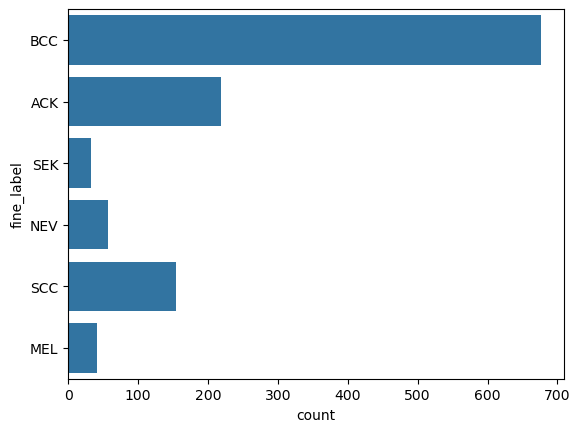

In [8]:
# Plot the class balance
sns.countplot(y_dev["fine_label"])

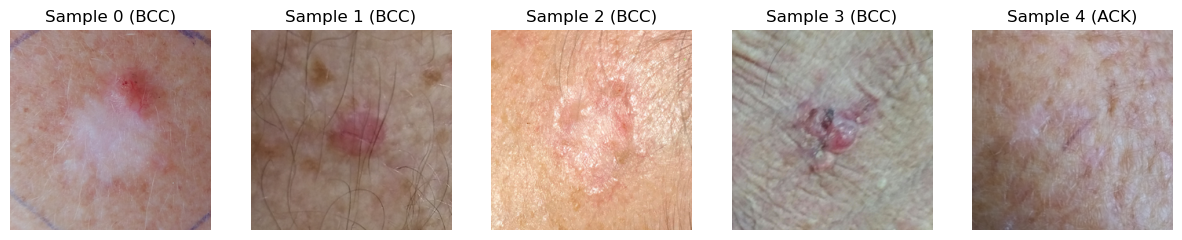

In [9]:
# Show the first 5 images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    axes[i].imshow(imgs[i])
    axes[i].axis('off')
    axes[i].set_title(f"Sample {i} ({y_dev.iloc[i]["fine_label"]})")

plt.show()

## Encode Categorical Features

We'll convert all categorical features to one-hot encodings, and all binary features to 1/0. 
We can auto-detect the binary features by looking for "True" and "False" (after manually looking through the data to confirm that's how these features are encoded.)

There also is a column labeled "gender". In publicly available datasets it can be especially tricky to figure out what a gender or sex column actually represents. Sometimes it's a patient's legal sex from government records, sometimes it's their biological sex from medical records, sometimes it's the clinician's assumption of the patient's gender, and sometimes it's the patient's self identified gender. The authors of this dataset provide a pdf of [the translated data collection instrument](https://pmc.ncbi.nlm.nih.gov/articles/instance/7479321/bin/mmc2.pdf) where we can see that gender is listed under "Questions About the Patient" and are phrased as questions the clinician would ask the patient directly. Therefore, in this case the gender column most likely represents patient self-identified gender. 

In [10]:
def preprocess_categorical_features(X, categorical_cols):
    """
    Preprocess categorical features in a DataFrame by converting True/False to 1/0,
    mapping gender to 0/1, and one-hot encoding specified categorical columns.
    
    Parameters:
    X (pandas.DataFrame): DataFrame to preprocess
    categorical_cols (list): List of column names to one-hot encode
    
    Returns:
    pandas.DataFrame: Preprocessed DataFrame
    """
    X = X.copy()  # Avoid modifying the original DataFrame
    
    # Get all obvious true/false cols that aren't already true/false
    for col in X.select_dtypes(include=['object']):
        if X[col].dropna().astype(str).str.contains('True|False').any():
            print(f"Automatically converting {col} to binary...")
            unmapped = X[~X[col].isin(['True','False'])][col].unique()
            print("The following values are being mapped to NaN in this column: ", unmapped)
            X[col] = X[col].map({'True': 1, 'False': 0, True: 1, False: 0})
    
    # Map gender if present
    if 'gender' in X.columns:
        X['gender'] = X['gender'].map({'MALE': 0, 'FEMALE': 1})
    
    # Handle the categorical data
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    
    encoded_feats = encoder.fit_transform(X[categorical_cols])
    encoded_df = pd.DataFrame(
        encoded_feats, 
        columns=encoder.get_feature_names_out(categorical_cols),
        index=X.index
    )
    
    # Drop original text columns and join the new numeric ones
    X = X.drop(columns=categorical_cols).join(encoded_df)
    
    return X

# These are the 3 columns in X that have categorical data.
# Everything else is binary or numeric. 
categorical_cols = ['region', 'background_father', 'background_mother']

# Preprocess X_dev
X_dev = preprocess_categorical_features(X_dev, categorical_cols)
X_test = preprocess_categorical_features(X_test, categorical_cols)

X_dev = X_dev.reindex(columns=X_test.columns, fill_value=0)
X_test = X_test.reindex(columns=X_dev.columns, fill_value=0)

Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting hurt to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting changed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting bleed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting elevation to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting hurt to binary...
The following values are being mapped to NaN

### Make age groups feature

In [11]:
age_groups = pd.cut(
    X_dev['age'], 
    bins=[0, 30, 60, 100], 
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)']
)

## Handle Missing Data

In [12]:
# First we'll calculate how much missing data there is
X_dev.isna().sum()

patient_id                         0
img_id                             0
smoke                              0
drink                              0
age                                0
pesticide                          0
gender                             0
skin_cancer_history                0
cancer_history                     0
has_piped_water                    0
has_sewage_system                  0
fitspatrick                        0
diameter_1                         0
diameter_2                         0
itch                               4
grew                             323
hurt                               8
changed                          319
bleed                              4
elevation                          2
color_std_R                        0
color_std_G                        0
color_std_B                        0
mean_brightness                    0
image_entropy                      0
region_ABDOMEN                     0
region_ARM                         0
r

In [13]:
# Then we'll decide what to do. For now we'll just treat missing data as false, 
# since it probably means that a patient didn't think the question was important or relevant.
X_dev = X_dev.fillna(0)
X_dev

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,background_mother_BRAZIL,background_mother_FRANCE,background_mother_GERMANY,background_mother_ITALY,background_mother_NETHERLANDS,background_mother_POLAND,background_mother_POMERANIA,background_mother_PORTUGAL,background_mother_SPAIN,background_mother_UNK
0,PAT_620,PAT_620_001,False,False,55,False,1,True,True,True,...,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,PAT_388,PAT_388_002,False,True,79,False,0,True,False,False,...,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,PAT_518,PAT_518_003,False,True,52,False,1,False,True,True,...,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,PAT_635,PAT_635_004,False,False,74,True,1,False,False,False,...,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,PAT_447,PAT_447_005,False,True,58,True,1,True,True,True,...,0.0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173,PAT_409,PAT_409_1470,True,False,66,False,0,True,False,True,...,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1174,PAT_640,PAT_640_1471,False,False,41,True,0,False,False,False,...,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1175,PAT_539,PAT_539_1472,False,False,43,True,1,True,True,False,...,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1176,PAT_620,PAT_620_1473,False,False,55,False,1,True,True,True,...,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [14]:
X_test.isna().sum()

patient_id                        0
img_id                            0
smoke                             0
drink                             0
age                               0
pesticide                         0
gender                            0
skin_cancer_history               0
cancer_history                    0
has_piped_water                   0
has_sewage_system                 0
fitspatrick                       0
diameter_1                        0
diameter_2                        0
itch                              2
grew                             79
hurt                              2
changed                          77
bleed                             2
elevation                         0
color_std_R                       0
color_std_G                       0
color_std_B                       0
mean_brightness                   0
image_entropy                     0
region_ABDOMEN                    0
region_ARM                        0
region_BACK                 

In [15]:
X_test = X_test.fillna(0)
X_test

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,background_mother_BRAZIL,background_mother_FRANCE,background_mother_GERMANY,background_mother_ITALY,background_mother_NETHERLANDS,background_mother_POLAND,background_mother_POMERANIA,background_mother_PORTUGAL,background_mother_SPAIN,background_mother_UNK
0,PAT_667,PAT_667_275,False,False,71,False,0,True,False,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,PAT_736,PAT_736_156,False,False,51,True,0,True,True,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PAT_628,PAT_628_085,True,False,58,True,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,PAT_461,PAT_461_083,False,False,80,False,0,False,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,PAT_059,PAT_059_262,False,False,38,False,0,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,PAT_307,PAT_307_189,False,False,75,False,1,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
292,PAT_321,PAT_321_072,False,False,71,False,1,False,True,True,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
293,PAT_152,PAT_152_107,False,False,67,True,0,False,True,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
294,PAT_526,PAT_526_271,False,False,62,True,1,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Your Code

You might want to revisit the above preprocessing steps for your Problem 2 model. You also might want to put some of the above code into functions to make it easier to apply to different datasets. 

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

RANDOM_SEED = 42

In [17]:
def ensure_numeric_cols(X):
    X_numeric = X.select_dtypes(include=['number', 'bool']).copy()
    bool_cols = X_numeric.select_dtypes(include=['bool']).columns
    if len(bool_cols):
        X_numeric[bool_cols] = X_numeric[bool_cols].astype(int)

    return X_numeric

In [18]:
# def cross_val(pl, kf, X, Y):
#     aucs = []
#     for train_index, val_index in kf.split(X):
#         # Handle both numpy arrays and DataFrames
#         if isinstance(X, np.ndarray):
#             x_train_fold = X[train_index]
#             x_val_fold = X[val_index]
#         else:
#             x_train_fold = X.iloc[train_index]
#             x_val_fold = X.iloc[val_index]
        
#         y_train_fold = Y['coarse_label'].iloc[train_index]
#         y_val_fold = Y['coarse_label'].iloc[val_index]

#         pl.fit(x_train_fold, y_train_fold)
#         y_pred_proba = pl.predict_proba(x_val_fold)[:, 1]

#         auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
#         aucs.append(auc)

#         return aucs

In [19]:
def embeddings_to_df(X, file):
    loaded_embeddings = np.load(file)

    # Flatten the embeddings from (N, 1280, 1, 1) to (N, 1280)
    flattened_embeddings = loaded_embeddings.squeeze()

    # Create a DataFrame from the flattened embeddings
    embeddings_df = pd.DataFrame(flattened_embeddings, index=X['img_id'])
    embeddings_df.columns = [f'embedding_{i}' for i in range(flattened_embeddings.shape[1])]

    # Reset index to make 'img_id' a column for merging
    embeddings_df = embeddings_df.reset_index()
    embeddings_df = embeddings_df.rename(columns={'index': 'img_id'})

    print(embeddings_df.shape)

    return embeddings_df

In [20]:
embeddings_df = embeddings_to_df(X_dev, 'image_embeddings.npy')
embeddings_df.set_index('img_id').reindex(y_dev.index).reset_index()
test_embeddings_df = embeddings_to_df(X_test, 'test_image_embeddings.npy')
test_embeddings_df = test_embeddings_df.reindex(columns=embeddings_df.columns, fill_value=0)

# Merge with y_aligned DataFrame
combined_df = pd.merge(X_dev, embeddings_df, on='img_id', how='left')
test_combined_df = pd.merge(X_test, test_embeddings_df, on='img_id', how='left')

embeddings_df = ensure_numeric_cols(embeddings_df)
test_embeddings_df = ensure_numeric_cols(test_embeddings_df)

combined_df = ensure_numeric_cols(combined_df)
test_combined_df = ensure_numeric_cols(test_combined_df)
test_combined_df = test_combined_df.reindex(columns=combined_df.columns, fill_value=0)

print(f"Shape of combined DataFrame: {combined_df.shape}")
display(combined_df.head())

print(f"Shape of combined test DataFrame: {test_combined_df.shape}")
display(test_combined_df.head())

(1178, 294)
(296, 142)
Shape of combined DataFrame: (1178, 349)


,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,...,embedding_283,embedding_284,embedding_285,embedding_286,embedding_287,embedding_288,embedding_289,embedding_290,embedding_291,embedding_292
0,0,0,55,0,1,1,1,1,1,3.0,...,0.119580,0.050010,0.309384,-0.068135,-0.091203,0.119197,-0.110562,-0.172053,0.414578,0.029424
1,0,1,79,0,0,1,0,0,0,1.0,...,0.004540,-0.129512,0.122106,0.038862,0.353867,-0.177408,0.313339,0.223391,0.091336,0.132030
2,0,1,52,0,1,0,1,1,1,3.0,...,0.028788,0.111944,-0.203845,0.160108,0.084246,-0.168881,0.155596,0.158394,0.468557,-0.022759
3,0,0,74,1,1,0,0,0,0,1.0,...,0.180957,-0.162925,0.384534,-0.378994,0.182322,-0.362779,0.081996,-0.011929,0.281133,0.022646
4,0,1,58,1,1,1,1,1,1,1.0,...,-0.205275,0.132927,0.174475,0.287354,0.044208,-0.158174,-0.000320,0.021599,0.213809,0.001321


Shape of combined test DataFrame: (296, 349)


,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,...,embedding_283,embedding_284,embedding_285,embedding_286,embedding_287,embedding_288,embedding_289,embedding_290,embedding_291,embedding_292
0,0,0,71,0,0,1,0,0,0,3.0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,51,1,0,1,1,0,0,2.0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,58,1,1,0,0,0,0,3.0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,80,0,0,0,1,1,1,3.0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,38,0,0,0,0,0,0,2.0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
# Split into train and validation sets
kf = sklearn.model_selection.KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

forest_hypers_grid_features = dict(
    max_features=[2, 12, 24, 36, 48, 58],
    max_depth=[6, 10, 16, 32],
    n_estimators=[100, 200, 500],
    )

forest_hypers_grid_embeddings = dict(
    max_features=[2, 60, 120, 180, 240, 294],
    max_depth=[8, 16, 32],
    n_estimators=[100, 200, 500],
    )

def search_params(X, y, grid, param='param_max_features'):
    rf = RandomForestClassifier(
        random_state=RANDOM_SEED,
        n_jobs=-1,  # Use all available cores
        class_weight='balanced',
    )

    searcher = sklearn.model_selection.GridSearchCV(
        estimator=rf,
        param_grid=grid,
        cv=kf,
        scoring='roc_auc',
        refit=False,
        return_train_score=True,
    )

    searcher.fit(X, y['coarse_label'])

    return searcher.best_params_, searcher.cv_results_

def plot_graph(param, best_params, cv_results):
    results_df = pd.DataFrame(cv_results)

    param = 'param_max_features'

    results_agg = (
        results_df[[param, 'mean_test_score', 'std_test_score',
                    'mean_train_score', 'std_train_score']]
        .groupby(param, as_index=False)
        .mean()
        .sort_values(param)
    )

    results_agg[param] = results_agg[param].astype(int)

    plt.figure(figsize=(8, 5))

    # Validation curve
    plt.errorbar(
        results_agg[param],
        results_agg['mean_test_score'],
        yerr=results_agg['std_test_score'],
        label='Validation ROC AUC',
        marker='o',
        capsize=4
    )

    # Training curve
    plt.errorbar(
        results_agg[param],
        results_agg['mean_train_score'],
        yerr=results_agg['std_train_score'],
        label='Training ROC AUC',
        marker='s',
        capsize=4
    )

    plt.title('Training vs Validation ROC AUC vs max_features')
    plt.xlabel('max_features')
    plt.ylabel('ROC AUC')

    plt.xticks(results_agg[param])
    plt.legend()
    plt.grid(True)

    plt.show()

    print("Printing a dict of the best hyperparameters")
    try:
        print(best_params)
    except AttributeError:
        print("AttributeError happens if you did not complete earlier 'Do the search' todo")

In [27]:
best_params_embeddings, cv_results_embeddings = search_params(embeddings_df, y_dev, forest_hypers_grid_embeddings)

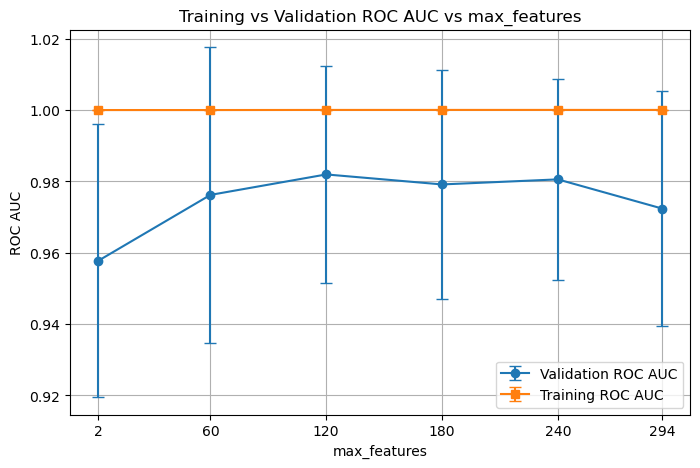

Printing a dict of the best hyperparameters
{'max_depth': 16, 'max_features': 120, 'n_estimators': 500}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",120
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [29]:
plot_graph('param_max_features', best_params_embeddings, cv_results_embeddings)

rf_embeddings = RandomForestClassifier().set_params(**best_params_embeddings)
rf_embeddings.fit(embeddings_df, y_dev['coarse_label'])

In [30]:
X_features = ensure_numeric_cols(X_dev)

# split data by age
mask = X_features["age"] < 60
X_under_60 = X_features[mask]
y_under_60 = y_dev[mask]

mask = X_features["age"] >= 60
X_60_plus = X_features[mask]
y_60_plus = y_dev[mask]

print(X_under_60.shape)
print(X_60_plus.shape)

(488, 56)
(690, 56)


In [31]:
best_params_under_60, cv_results_features_under_60 = search_params(X_under_60, y_under_60, forest_hypers_grid_features)
best_params_60_plus, cv_results_features_60_plus = search_params(X_60_plus, y_60_plus, forest_hypers_grid_features)

In [32]:
from sklearn.ensemble import VotingClassifier

rf_under_60 = RandomForestClassifier().set_params(**best_params_under_60)
rf_60_plus = RandomForestClassifier().set_params(**best_params_60_plus)

ensemble = VotingClassifier(
    estimators=[('rf_under_60', rf_under_60), ('rf_60_plus', rf_60_plus)],
    voting='soft'  # or 'hard'
)

ensemble.fit(X_features, y_dev['coarse_label'])

X_test_features = ensure_numeric_cols(X_test)
X_test_features = X_test_features.reindex(columns=X_features.columns, fill_value=0)

In [35]:
train_index, val_index = next(kf.split(X_features))

x_train_fold_features = X_features.iloc[train_index]
x_train_fold_embeddings = embeddings_df.iloc[train_index]
y_train_fold = y_dev['coarse_label'].iloc[train_index]

rf_embeddings.fit(x_train_fold_embeddings, y_train_fold)
ensemble.fit(x_train_fold_features, y_train_fold)

x_val_fold_features = X_features.iloc[val_index]
x_val_fold_embeddings = embeddings_df.iloc[val_index]
y_val_fold = y_dev['coarse_label'].iloc[val_index]

y_preds_embeddings = rf_embeddings.predict_proba(x_val_fold_embeddings)[:, 1]
y_preds_features = ensemble.predict_proba(x_val_fold_features)[:, 1]

y_preds = y_preds_embeddings * 0.5 + y_preds_features * 0.5

y_preds = y_preds_embeddings * 0.5 + y_preds_features * 0.5
y_pred = (y_preds > 0.5).astype(int)
confidence = np.abs(y_preds - 0.5)

df = pd.DataFrame({
    'y_true': y_val_fold,
    'y_pred': y_pred,
    'y_prob': y_preds,
    'confidence': confidence,
})

df['correct'] = df['y_true'] == df['y_pred']

most_confident_correct = df[df['correct']].sort_values('confidence', ascending=False).head(3)
most_confident_incorrect = df[~df['correct']].sort_values('confidence', ascending=False).head(3)

print("Most confidently correct:")
print(most_confident_correct)

print("\nMost confidently incorrect:")
print(most_confident_incorrect)

Most confidently correct:
     y_true  y_pred    y_prob  confidence  correct
614       1       1  0.993582    0.493582     True
420       1       1  0.992818    0.492818     True
844       1       1  0.990919    0.490919     True

Most confidently incorrect:
     y_true  y_pred    y_prob  confidence  correct
244       0       1  0.922022    0.422022    False
380       0       1  0.776058    0.276058    False
602       0       1  0.741860    0.241860    False


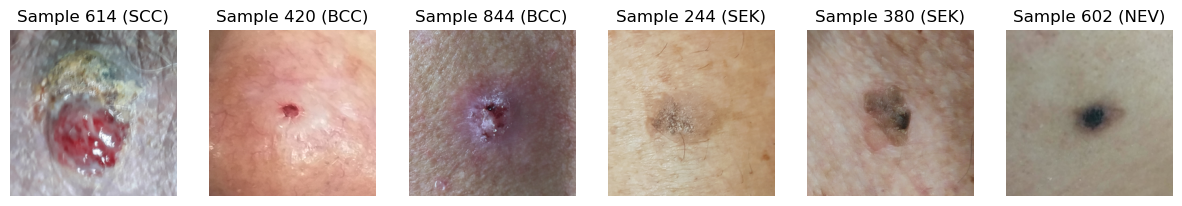

In [39]:
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
top3s = [614, 420, 844, 244, 380, 602]
for index, id in enumerate(top3s):
    axes[index].imshow(imgs[id])
    axes[index].axis('off')
    axes[index].set_title(f"Sample {id} ({y_dev.iloc[id]["fine_label"]})")

plt.show()

In [ ]:
# weights = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# best_auc = 0
# best_weight = None

# for w in weights:
#     aucs = []
#     for train_index, val_index in kf.split(X_features):
#         x_train_fold_features = X_features.iloc[train_index]
#         x_train_fold_embeddings = embeddings_df.iloc[train_index]
#         y_train_fold = y_dev['coarse_label'].iloc[train_index]

#         rf_embeddings.fit(x_train_fold_embeddings, y_train_fold)
#         ensemble.fit(x_train_fold_features, y_train_fold)
        
#         x_val_fold_features = X_features.iloc[val_index]
#         x_val_fold_embeddings = embeddings_df.iloc[val_index]
#         y_val_fold = y_dev['coarse_label'].iloc[val_index]
        
#         y_preds_embeddings = rf_embeddings.predict_proba(x_val_fold_embeddings)[:, 1]
#         y_preds_features = ensemble.predict_proba(x_val_fold_features)[:, 1]

#         y_preds = y_preds_embeddings * w + y_preds_features * (1 - w)

#         auc = sklearn.metrics.roc_auc_score(y_val_fold, y_preds)
#         aucs.append(auc)
#     mean_auc = np.mean(aucs)
#     if mean_auc > best_auc:
#         best_auc = mean_auc
#         best_weight = w

In [ ]:
y_preds_embeddings = rf_embeddings.predict_proba(test_embeddings_df)[:, 1]
y_preds_features = ensemble.predict_proba(X_test_features)[:, 1]
best_weight = 0.5
y_preds = y_preds_embeddings * best_weight + y_preds_features * (1 - best_weight)

with open("preds/yproba1_test.txt", "w") as f:
    for pred in y_preds:
        f.write(f"{pred}\n")